In [1]:
# Level 2 - Task 1: Regression Analysis

## House Value Prediction Using Simple Linear Regression

#This project investigates whether the average number of rooms
#can be used to predict median house value using a simple
#linear regression model.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
#The provided dataset does not contain column headers.
#Based on its structure and values, it corresponds to the Boston Housing dataset.
#Therefore, the standard Boston Housing feature names were assigned to the columns.

In [4]:
columns = [
    "CRIM", "ZN", "INDUS", "CHAS", "NOX",
    "RM", "AGE", "DIS", "RAD", "TAX",
    "PTRATIO", "B", "LSTAT", "MEDV"
]

In [5]:
df = pd.read_csv(
    r"D:\projects\codveda project\csv\4) house Prediction Data Set.csv",
    sep=r"\s+",
    header=None,
    names=columns
)

In [6]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


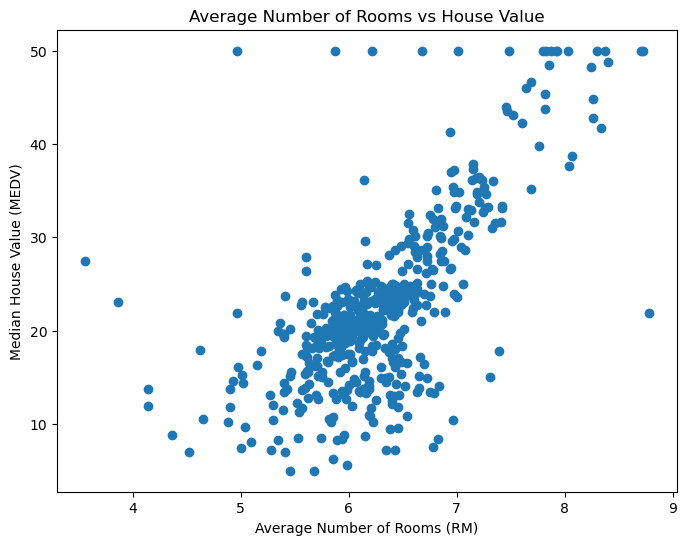

In [7]:
plt.figure(figsize=(8, 6))

plt.scatter(df["RM"], df["MEDV"])

plt.title("Average Number of Rooms vs House Value")
plt.xlabel("Average Number of Rooms (RM)")
plt.ylabel("Median House Value (MEDV)")
plt.show()

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
X = df[["RM"]]
y = df["MEDV"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("Training targets:", y_train.shape)
print("Testing targets:", y_test.shape)

Training features: (404, 1)
Testing features: (102, 1)
Training targets: (404,)
Testing targets: (102,)


In [12]:
from sklearn.linear_model import LinearRegression

In [13]:
model = LinearRegression()

In [14]:
model.fit(X_train, y_train)

LinearRegression()

In [15]:
print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

Coefficient: 9.348301406497727
Intercept: -36.24631889813795


In [16]:
y_pred = model.predict(X_test)

In [17]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
173,23.6,23.732383
274,32.4,26.929502
491,13.6,19.684568
72,22.8,20.451129
452,16.1,22.619935
76,20.0,22.451666
316,17.8,19.039536
140,14.0,21.470094
471,19.6,21.984251
500,16.8,20.095894


In [19]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R-squared:", r2)

MSE: 46.144775347317264
R-squared: 0.3707569232254778


In [20]:
rmse = mse ** 0.5
print("RMSE:", rmse)

RMSE: 6.792994578778734


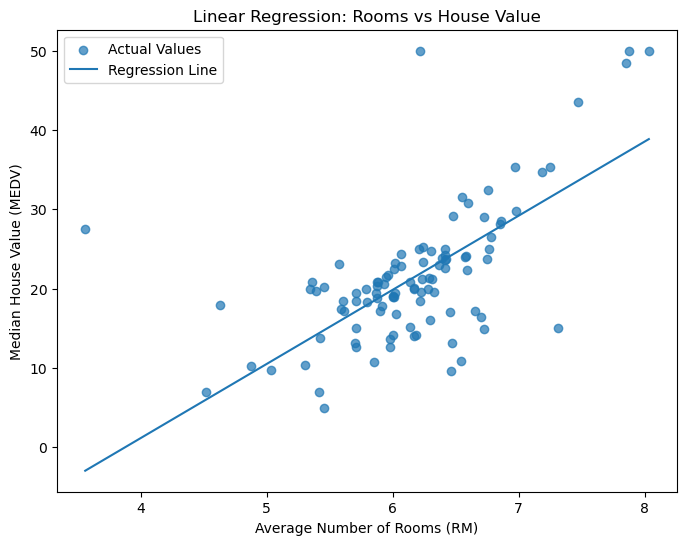

In [23]:
import numpy as np

# Create 100 ordered RM values
x_line = pd.DataFrame({
    "RM": np.linspace(
        X_test["RM"].min(),
        X_test["RM"].max(),
        100
    )
})

# Predict MEDV for those RM values
y_line = model.predict(x_line)

# Plot
plt.figure(figsize=(8, 6))

plt.scatter(
    X_test["RM"],
    y_test,
    label="Actual Values",
    alpha=0.7
)

plt.plot(
    x_line["RM"],
    y_line,
    label="Regression Line"
)

plt.title("Linear Regression: Rooms vs House Value")
plt.xlabel("Average Number of Rooms (RM)")
plt.ylabel("Median House Value (MEDV)")
plt.legend()

plt.show()

In [22]:
### Regression Model Interpretation

#The regression line shows a positive relationship between the average number
#of rooms and median house value.

#The model coefficient is approximately 9.35, indicating that a one-unit
#increase in the average number of rooms is associated with an increase of
#about 9.35 units in predicted MEDV.

#However, many observations are located far from the regression line,
#showing that the number of rooms alone cannot fully explain house values.

#The model achieved an R-squared value of approximately 0.37, meaning that
#around 37% of the variation in MEDV is explained by RM alone.

In [24]:
## Final Conclusion

#A simple linear regression model was developed to examine the relationship
#between the average number of rooms (RM) and median house value (MEDV).

#The scatter plot and fitted regression line show a clear positive relationship:
#areas with a higher average number of rooms generally tend to have higher
#median house values.

#The model coefficient was approximately 9.35, meaning that a one-unit increase
#in RM is associated with an increase of about 9.35 units in the predicted MEDV.

#The model achieved an R-squared value of approximately 0.37. This indicates
#that RM alone explains about 37% of the variation in MEDV. The Mean Squared
#Error was approximately 46.14, with an RMSE of about 6.79.

#The regression plot also shows several observations located far from the fitted
#line, indicating that the average number of rooms alone is not sufficient for
#accurate house-value prediction. Other housing and neighborhood characteristics
#likely contribute substantially to MEDV.

#Overall, the analysis demonstrates a meaningful positive relationship between
#RM and MEDV, while also showing the limitations of using a single predictor in
#a simple linear regression model.